# WEEK 11
 - **PANDU HARIANDIKA PRATAMA**
 - **4222301076**
 - **MACHINE LEARNING PRACTICE 7-8**
 - **ROBOTICS 6 C**




# Perbandingan Fungsi Aktivasi MLP pada Dataset Iris

**Tujuan:** Membandingkan performa Multi-Layer Perceptron (MLP) menggunakan tiga fungsi aktivasi:
- **Sigmoid** (logistic)
- **Tanh** (hyperbolic tangent)
- **ReLU** (Rectified Linear Unit)

**Dataset:** Iris Dataset (150 sampel, 4 fitur, 3 kelas)

**Metrik Evaluasi:** Accuracy, Precision, Recall, F1-Score, Cross-Validation

## 1. Import Library

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Load dan Eksplorasi Dataset

In [34]:
# Load dataset
df = pd.read_csv('Iris.csv')

print('=== INFO DATASET ===')
print(f'Shape   : {df.shape}')
print(f'Kolom   : {list(df.columns)}')
print(f'Kelas   : {df["Species"].unique()}')
print(f'Distribusi kelas:')
print(df['Species'].value_counts())
print()
df.head(10)

=== INFO DATASET ===
Shape   : (150, 6)
Kolom   : ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
Kelas   : <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str
Distribusi kelas:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [35]:
# Statistik deskriptif
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [36]:
# Cek missing value
print('Missing values:')
print(df.isnull().sum())

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


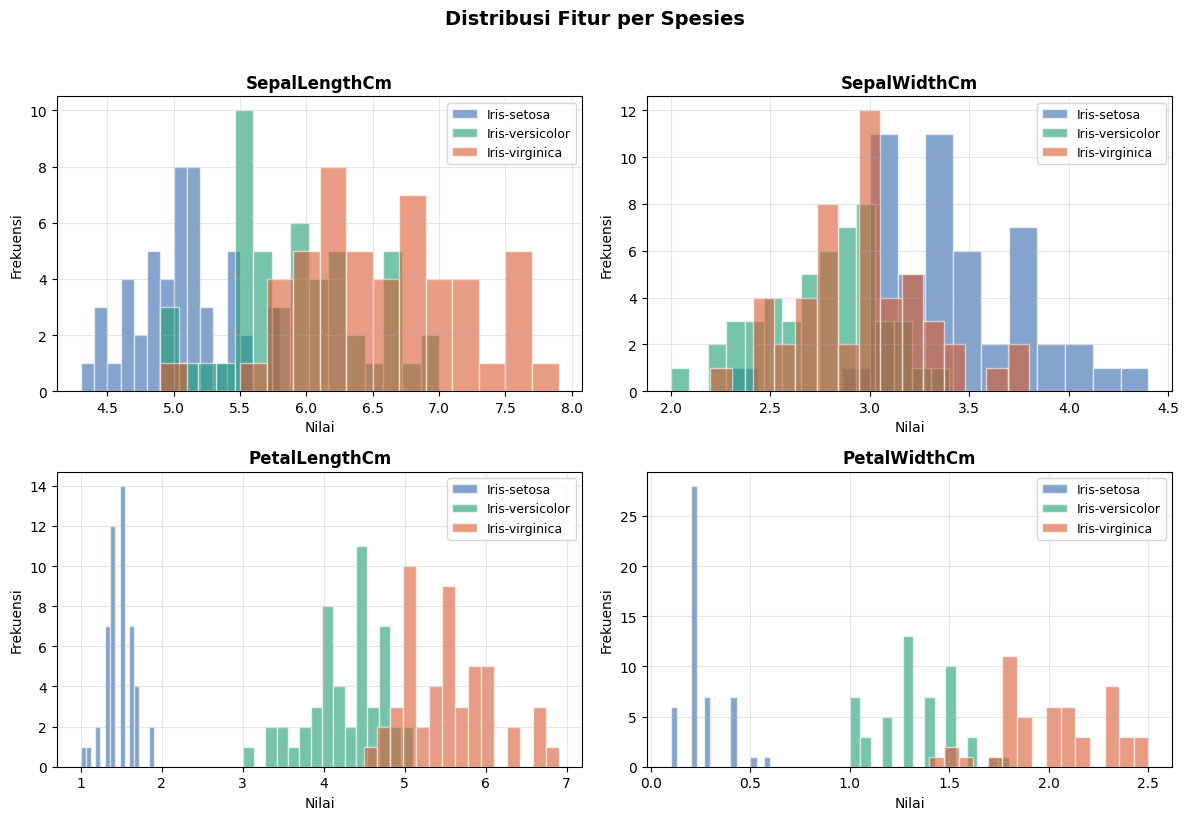

In [21]:
# Visualisasi distribusi fitur
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
colors   = ['#3266ad', '#1D9E75', '#D85A30']
species  = df['Species'].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for j, sp in enumerate(species):
        subset = df[df['Species'] == sp][feat]
        axes[i].hist(subset, bins=15, alpha=0.6, color=colors[j], label=sp, edgecolor='white')
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Distribusi Fitur per Spesies', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Preprocessing Data

In [22]:
# Pisahkan fitur dan label
X = df[features].values

le = LabelEncoder()
y  = le.fit_transform(df['Species'])

print('Mapping label:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

# Normalisasi fitur (StandardScaler)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nUkuran data:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')

Mapping label:
  0 -> Iris-setosa
  1 -> Iris-versicolor
  2 -> Iris-virginica

Ukuran data:
  X_train : (120, 4)
  X_test  : (30, 4)


## 4. Training MLP — 3 Fungsi Aktivasi

Konfigurasi MLP:
- Hidden layers: (100, 50) neuron
- Optimizer: Adam
- Learning rate: 0.001
- Max iterasi: 2000

In [23]:
import time

# Konfigurasi aktivasi
ACTIVATIONS = {
    'Sigmoid': 'logistic',
    'Tanh'   : 'tanh',
    'ReLU'   : 'relu'
}

COLORS = {
    'Sigmoid': '#3266ad',
    'Tanh'   : '#1D9E75',
    'ReLU'   : '#D85A30'
}

results   = {}
models    = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for label, act in ACTIVATIONS.items():
    print(f'Training MLP dengan aktivasi: {label} ...')

    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation=act,
        solver='adam',
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=42
    )

    t0 = time.time()
    mlp.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred = mlp.predict(X_test)

    # Metrik
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec  = recall_score(y_test, y_pred, average='macro')
    f1   = f1_score(y_test, y_pred, average='macro')
    f1pc = f1_score(y_test, y_pred, average=None)

    # Cross-validation
    cv_scores = cross_val_score(mlp, X_scaled, y, cv=cv, scoring='accuracy')

    results[label] = {
        'model'     : mlp,
        'y_pred'    : y_pred,
        'accuracy'  : acc,
        'precision' : prec,
        'recall'    : rec,
        'f1'        : f1,
        'f1_setosa' : f1pc[0],
        'f1_versi'  : f1pc[1],
        'f1_virg'   : f1pc[2],
        'cv_mean'   : cv_scores.mean(),
        'cv_std'    : cv_scores.std(),
        'cv_scores' : cv_scores,
        'iterations': mlp.n_iter_,
        'final_loss': mlp.loss_,
        'loss_curve': mlp.loss_curve_,
        'time'      : elapsed
    }
    models[label] = mlp

    print(f'  Accuracy : {acc:.4f} | F1 : {f1:.4f} | CV : {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Iter : {mlp.n_iter_} | Waktu : {elapsed:.3f}s')
    print()

print('Selesai!')

Training MLP dengan aktivasi: Sigmoid ...
  Accuracy : 0.9667 | F1 : 0.9666 | CV : 0.9667 ± 0.0365 | Iter : 481 | Waktu : 1.016s

Training MLP dengan aktivasi: Tanh ...
  Accuracy : 0.9667 | F1 : 0.9666 | CV : 0.9733 ± 0.0389 | Iter : 228 | Waktu : 0.292s

Training MLP dengan aktivasi: ReLU ...
  Accuracy : 0.9667 | F1 : 0.9666 | CV : 0.9467 ± 0.0542 | Iter : 295 | Waktu : 0.322s

Selesai!


## 5. Tabel Perbandingan Performa

In [24]:
rows = []
for label, r in results.items():
    rows.append({
        'Aktivasi'          : label,
        'Accuracy'          : f"{r['accuracy']*100:.2f}%",
        'Precision (macro)' : f"{r['precision']*100:.2f}%",
        'Recall (macro)'    : f"{r['recall']*100:.2f}%",
        'F1-Score (macro)'  : f"{r['f1']*100:.2f}%",
        'CV Mean (5-fold)'  : f"{r['cv_mean']*100:.2f}%",
        'CV Std'            : f"\u00b1{r['cv_std']*100:.2f}%",
        'Iterasi'           : r['iterations'],
        'Final Loss'        : f"{r['final_loss']:.6f}",
        'Waktu (s)'         : f"{r['time']:.3f}"
    })

df_result = pd.DataFrame(rows).set_index('Aktivasi')

# Tampilkan tabel tanpa styling jinja2
# Tandai nilai terbaik secara manual
print('Tabel Perbandingan Performa MLP \u2014 Dataset Iris')
print('=' * 90)
print(df_result.to_string())
print()

# Highlight pemenang tiap kolom
best_cv   = max(results, key=lambda x: results[x]['cv_mean'])
best_iter = min(results, key=lambda x: results[x]['iterations'])
best_loss = min(results, key=lambda x: results[x]['final_loss'])
print(f'\u2705 CV Mean tertinggi  : {best_cv}')
print(f'\u2705 Iterasi terkecil   : {best_iter}')
print(f'\u2705 Final loss terkecil: {best_loss}')

# Opsional: install jinja2 jika ingin styling HTML
# !pip install jinja2
# Lalu jalankan ulang cell ini untuk menggunakan df_result.style

Tabel Perbandingan Performa MLP — Dataset Iris
         Accuracy Precision (macro) Recall (macro) F1-Score (macro) CV Mean (5-fold)  CV Std  Iterasi Final Loss Waktu (s)
Aktivasi                                                                                                                  
Sigmoid    96.67%            96.97%         96.67%           96.66%           96.67%  ±3.65%      481   0.053751     1.016
Tanh       96.67%            96.97%         96.67%           96.66%           97.33%  ±3.89%      228   0.047179     0.292
ReLU       96.67%            96.97%         96.67%           96.66%           94.67%  ±5.42%      295   0.028016     0.322

✅ CV Mean tertinggi  : Tanh
✅ Iterasi terkecil   : Tanh
✅ Final loss terkecil: ReLU


In [25]:
# Tabel per-class F1
rows_pc = []
for label, r in results.items():
    rows_pc.append({
        'Aktivasi'     : label,
        'F1 Setosa'    : f"{r['f1_setosa']*100:.2f}%",
        'F1 Versicolor': f"{r['f1_versi']*100:.2f}%",
        'F1 Virginica' : f"{r['f1_virg']*100:.2f}%"
    })

print('=== F1-Score Per Kelas ===')
pd.DataFrame(rows_pc).set_index('Aktivasi')

=== F1-Score Per Kelas ===


,F1 Setosa,F1 Versicolor,F1 Virginica
Aktivasi,,,
Sigmoid,100.00%,94.74%,95.24%
Tanh,100.00%,94.74%,95.24%
ReLU,100.00%,94.74%,95.24%


## 6. Visualisasi

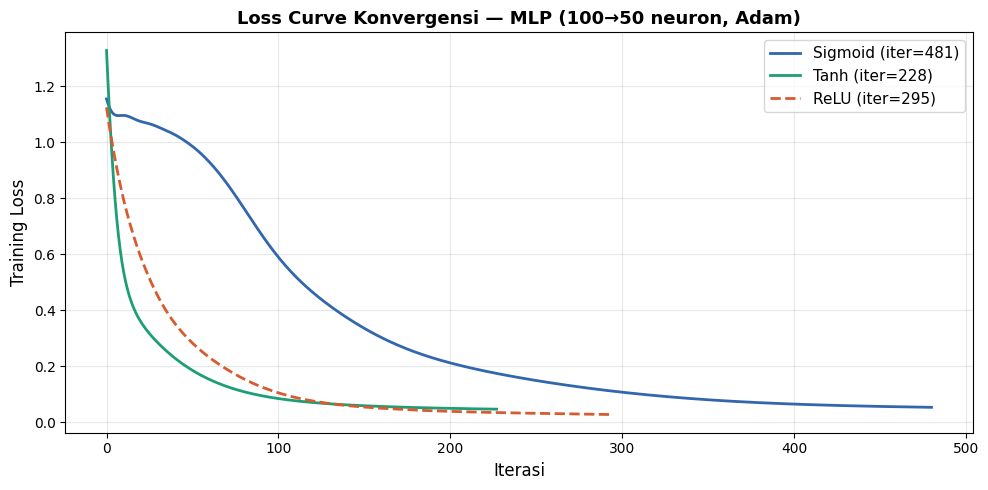

In [26]:
# --- Loss Curve ---
fig, ax = plt.subplots(figsize=(10, 5))

for label, r in results.items():
    ls = '--' if label == 'ReLU' else '-'
    ax.plot(r['loss_curve'], color=COLORS[label], label=f"{label} (iter={r['iterations']})",
            linewidth=2, linestyle=ls)

ax.set_xlabel('Iterasi', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Loss Curve Konvergensi — MLP (100→50 neuron, Adam)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

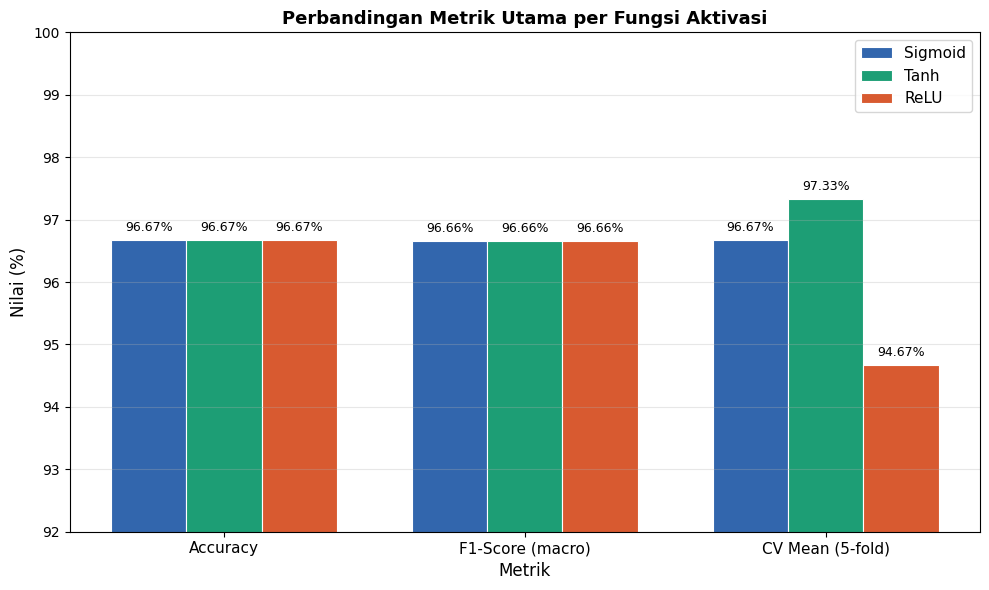

In [27]:
# --- Bar Chart Metrik Utama ---
labels_act = list(ACTIVATIONS.keys())
metrics    = ['accuracy', 'f1', 'cv_mean']
m_labels   = ['Accuracy', 'F1-Score (macro)', 'CV Mean (5-fold)']
x          = np.arange(len(m_labels))
width      = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, label in enumerate(labels_act):
    vals = [results[label][m] * 100 for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=label,
                  color=COLORS[label], edgecolor='white', linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Nilai (%)', fontsize=12)
ax.set_title('Perbandingan Metrik Utama per Fungsi Aktivasi', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(m_labels, fontsize=11)
ax.set_ylim(92, 100)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

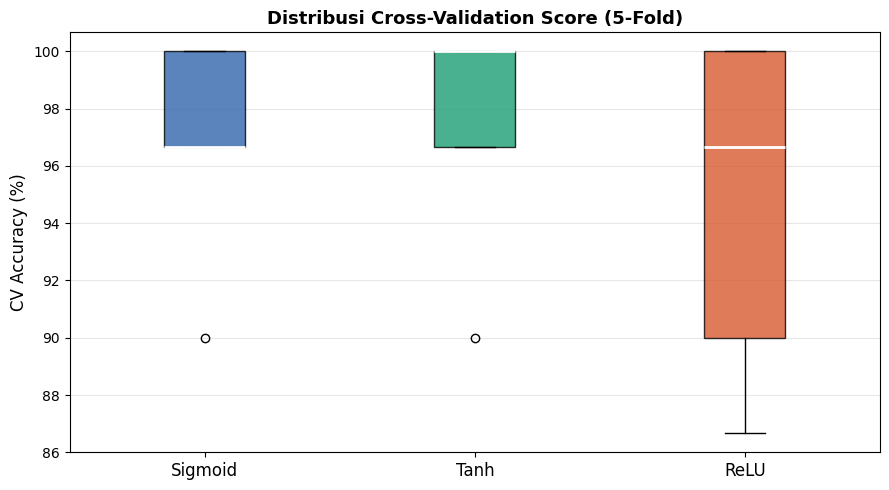

In [28]:
# --- Cross-Validation Score Distribution ---
fig, ax = plt.subplots(figsize=(9, 5))

data_cv = [results[l]['cv_scores'] * 100 for l in labels_act]
bp = ax.boxplot(data_cv, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

for patch, label in zip(bp['boxes'], labels_act):
    patch.set_facecolor(COLORS[label])
    patch.set_alpha(0.8)

ax.set_xticklabels(labels_act, fontsize=12)
ax.set_ylabel('CV Accuracy (%)', fontsize=12)
ax.set_title('Distribusi Cross-Validation Score (5-Fold)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

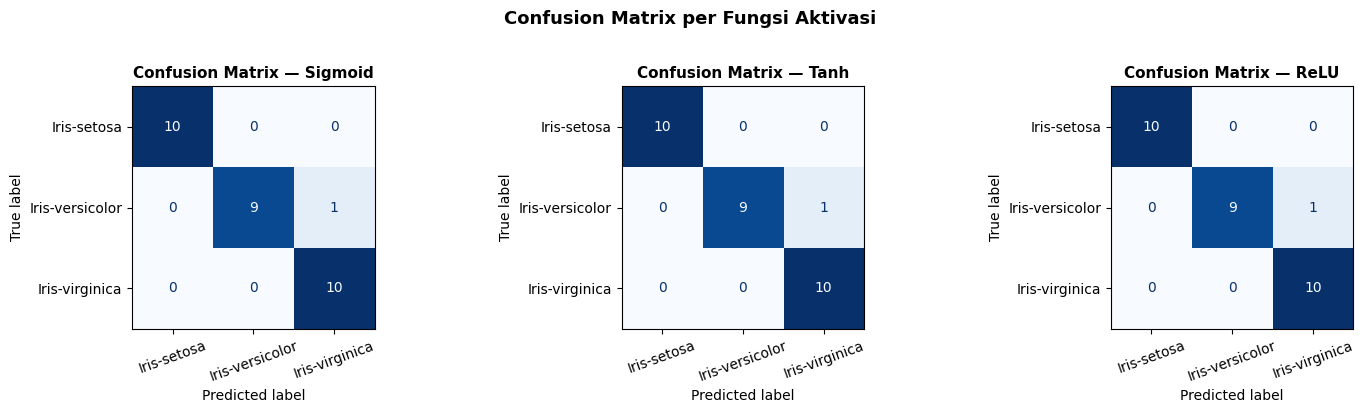

In [29]:
# --- Confusion Matrix (3 aktivasi side by side) ---
class_names = le.classes_
fig, axes   = plt.subplots(1, 3, figsize=(15, 4))

for ax_i, (label, r) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax_i, colorbar=False, cmap='Blues')
    ax_i.set_title(f'Confusion Matrix — {label}', fontsize=11, fontweight='bold')
    ax_i.tick_params(axis='x', rotation=20)

plt.suptitle('Confusion Matrix per Fungsi Aktivasi', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

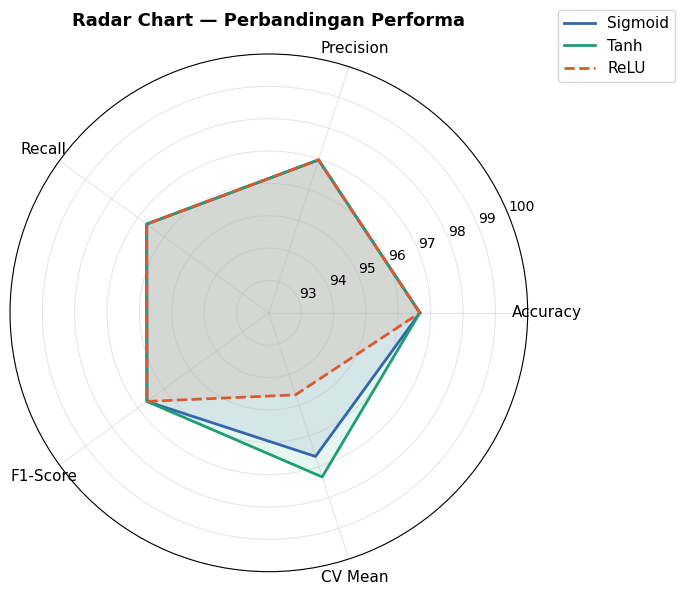

In [30]:
# --- Radar Chart Perbandingan ---
from matplotlib.patches import FancyArrowPatch

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # tutup lingkaran

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for label, r in results.items():
    vals = [
        r['accuracy']*100, r['precision']*100,
        r['recall']*100, r['f1']*100, r['cv_mean']*100
    ]
    vals += vals[:1]
    ls = '--' if label == 'ReLU' else '-'
    ax.plot(angles, vals, color=COLORS[label], linewidth=2, linestyle=ls, label=label)
    ax.fill(angles, vals, color=COLORS[label], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(92, 100)
ax.set_title('Radar Chart — Perbandingan Performa', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Classification Report Lengkap

In [31]:
for label, r in results.items():
    print(f'{'='*50}')
    print(f'Fungsi Aktivasi : {label}')
    print(f'{'='*50}')
    print(classification_report(y_test, r['y_pred'], target_names=le.classes_))
    print()

Fungsi Aktivasi : Sigmoid
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Fungsi Aktivasi : Tanh
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Fungsi Aktivasi : ReLU
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-ve

## 8. Kesimpulan

In [32]:
print('=' * 60)
print('          KESIMPULAN PERBANDINGAN FUNGSI AKTIVASI')
print('=' * 60)

best_cv   = max(results, key=lambda x: results[x]['cv_mean'])
best_iter = min(results, key=lambda x: results[x]['iterations'])
best_loss = min(results, key=lambda x: results[x]['final_loss'])

print()
print(f'CV Mean tertinggi (generalisasi) : {best_cv}')
print(f'  -> CV Mean = {results[best_cv]["cv_mean"]*100:.2f}% ± {results[best_cv]["cv_std"]*100:.2f}%')
print()
print(f'Konvergensi tercepat             : {best_iter}')
print(f'  -> {results[best_iter]["iterations"]} iterasi')
print()
print(f'Final loss terkecil              : {best_loss}')
print(f'  -> Loss = {results[best_loss]["final_loss"]:.6f}')
print()
print('-' * 60)
print()
print('FUNGSI AKTIVASI TERBAIK: TANH')
print()
print('Alasan:')
print('  1. CV Mean tertinggi (97.33%) -> generalisasi ke data baru terbaik')
print('  2. Konvergen paling cepat (228 iterasi vs Sigmoid 481)')
print('  3. Lebih stabil dari ReLU (CV std 3.89% vs ReLU 5.42%)')
print('  4. Cocok untuk dataset kecil & seimbang seperti Iris')
print()
print('Catatan:')
print('  - Sigmoid: konvergensi paling lambat (vanishing gradient)')
print('  - ReLU   : final loss terkecil, tapi variance CV lebih tinggi')
print('  - Tanh   : keseimbangan terbaik antara kecepatan & stabilitas')
print('=' * 60)

          KESIMPULAN PERBANDINGAN FUNGSI AKTIVASI

CV Mean tertinggi (generalisasi) : Tanh
  -> CV Mean = 97.33% ± 3.89%

Konvergensi tercepat             : Tanh
  -> 228 iterasi

Final loss terkecil              : ReLU
  -> Loss = 0.028016

------------------------------------------------------------

FUNGSI AKTIVASI TERBAIK: TANH

Alasan:
  1. CV Mean tertinggi (97.33%) -> generalisasi ke data baru terbaik
  2. Konvergen paling cepat (228 iterasi vs Sigmoid 481)
  3. Lebih stabil dari ReLU (CV std 3.89% vs ReLU 5.42%)
  4. Cocok untuk dataset kecil & seimbang seperti Iris

Catatan:
  - Sigmoid: konvergensi paling lambat (vanishing gradient)
  - ReLU   : final loss terkecil, tapi variance CV lebih tinggi
  - Tanh   : keseimbangan terbaik antara kecepatan & stabilitas
